In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from google.colab import files

uploaded = files.upload()
df = pd.read_csv("Sales_dataset (2).csv")
df.head()
df.info()
df.isnull().sum()
df.describe()


Saving Sales_dataset.csv to Sales_dataset (4).csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      36 non-null     object
 1   Sales     36 non-null     int64 
 2   Profit    36 non-null     int64 
 3   Quantity  36 non-null     int64 
 4   Discount  36 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 1.5+ KB


,Sales,Profit,Quantity,Discount
count,36.000000,36.000000,36.000000,36.000000
mean,2751.111111,550.222222,29.444444,1.694444
std,1054.597493,210.919499,11.246446,1.785968
min,1200.000000,240.000000,12.000000,0.000000
25%,1832.500000,366.500000,19.750000,0.000000
50%,2615.000000,523.000000,28.500000,1.000000
75%,3582.500000,716.500000,38.250000,3.000000
max,4750.000000,950.000000,50.000000,6.000000


In [11]:
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

df.head()


,Date,Sales,Profit,Quantity,Discount,Year,Month
0,2023-01-01,1200,240,12,5,2023,1
1,2023-02-01,1350,270,14,4,2023,2
2,2023-03-01,1280,256,13,6,2023,3
3,2023-04-01,1450,290,15,5,2023,4
4,2023-05-01,1520,304,16,4,2023,5


In [12]:
df.dtypes

,0
Date,datetime64[ns]
Sales,int64
Profit,int64
Quantity,int64
Discount,int64
Year,int32
Month,int32


In [13]:
X = df[['Profit', 'Quantity', 'Discount', 'Year', 'Month']]
y = df['Sales']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (28, 5)
Testing Data: (8, 5)


In [16]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(y_pred)

comparison = pd.DataFrame({
    'Actual Sales': y_test,
    'Predicted Sales': y_pred
})

comparison.head(10)
comparison

[4750. 2150. 3550. 4050. 2480. 4180. 2950. 2200.]


,Actual Sales,Predicted Sales
35,4750,4750.0
13,2150,2150.0
26,3550,3550.0
30,4050,4050.0
16,2480,2480.0
31,4180,4180.0
21,2950,2950.0
12,2200,2200.0


In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")



Mean Absolute Error (MAE): 4.547473508864641e-13
Mean Squared Error (MSE): 3.101927297073854e-25
Root Mean Squared Error (RMSE): 5.569494857771083e-13
R² Score: 1.0
MAE  : 0.00
RMSE : 0.00
R²   : 1.0000


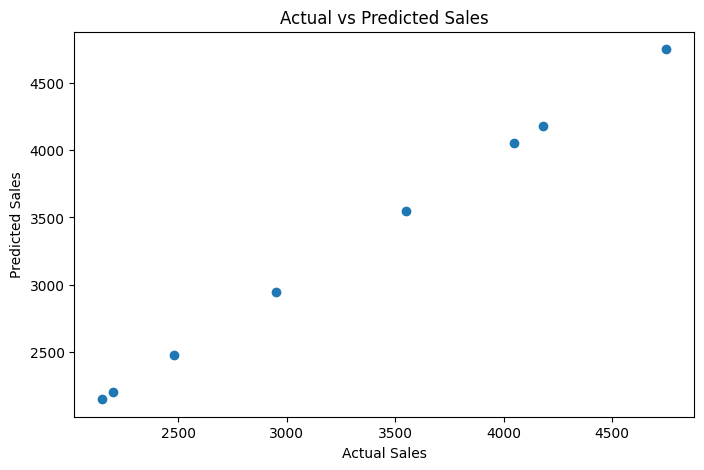

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

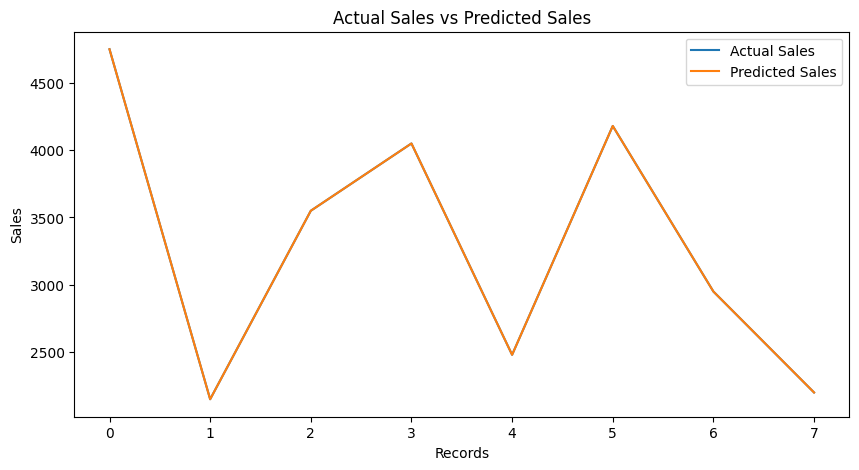

In [21]:
comparison_sorted = comparison.reset_index(drop=True)

plt.figure(figsize=(10,5))
plt.plot(comparison_sorted['Actual Sales'], label='Actual Sales')
plt.plot(comparison_sorted['Predicted Sales'], label='Predicted Sales')
plt.title("Actual Sales vs Predicted Sales")
plt.xlabel("Records")
plt.ylabel("Sales")
plt.legend()
plt.show()

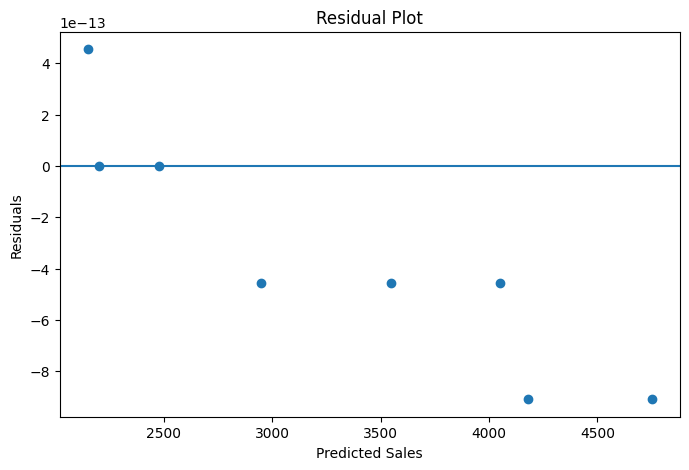

In [22]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

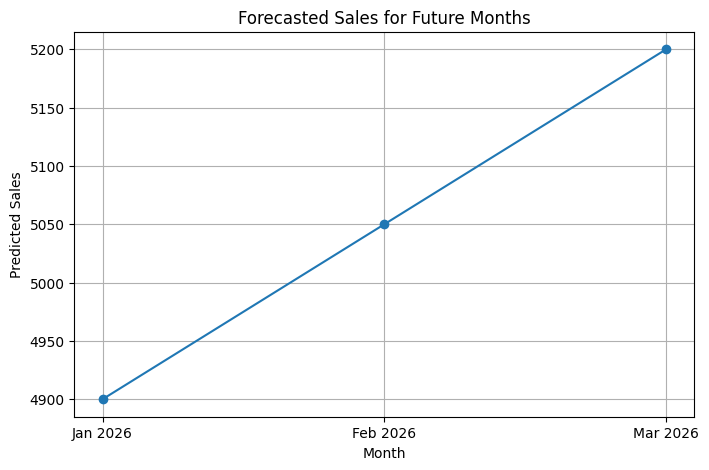

In [25]:
future_data = pd.DataFrame({
    'Profit': [980, 1010, 1040],
    'Quantity': [52, 54, 56],
    'Discount': [0, 0, 0],
    'Year': [2026, 2026, 2026],
    'Month': [1, 2, 3]
})

future_data
future_predictions = model.predict(future_data)

future_predictions

forecast = pd.DataFrame({
    'Month': ['Jan 2026', 'Feb 2026', 'Mar 2026'],
    'Predicted Sales': future_predictions
})

forecast

plt.figure(figsize=(8,5))

plt.plot(
    forecast['Month'],
    forecast['Predicted Sales'],
    marker='o'
)

plt.title("Forecasted Sales for Future Months")
plt.xlabel("Month")
plt.ylabel("Predicted Sales")

plt.grid(True)

plt.show()

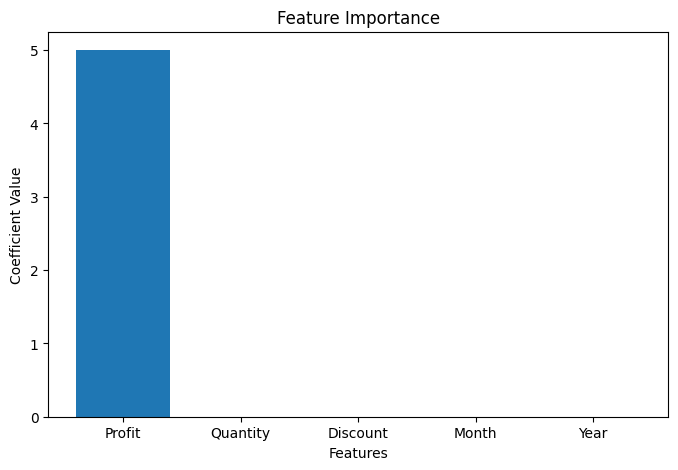

In [27]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

feature_importance.sort_values(
    by='Coefficient',
    ascending=False
)

feature_importance = feature_importance.sort_values(
    by='Coefficient',
    ascending=False
)

plt.figure(figsize=(8,5))

plt.bar(
    feature_importance['Feature'],
    feature_importance['Coefficient']
)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Coefficient Value")

plt.show()

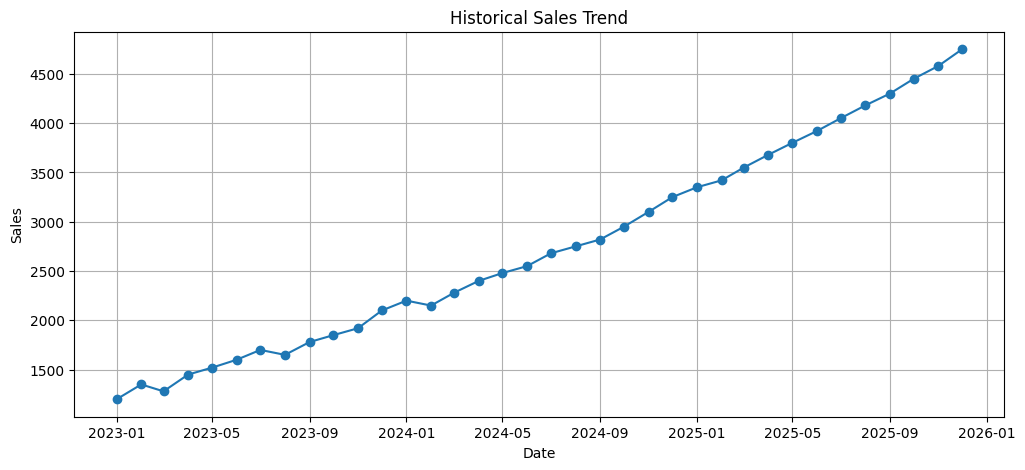

In [28]:
plt.figure(figsize=(12,5))

plt.plot(
    df['Date'],
    df['Sales'],
    marker='o'
)

plt.title("Historical Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

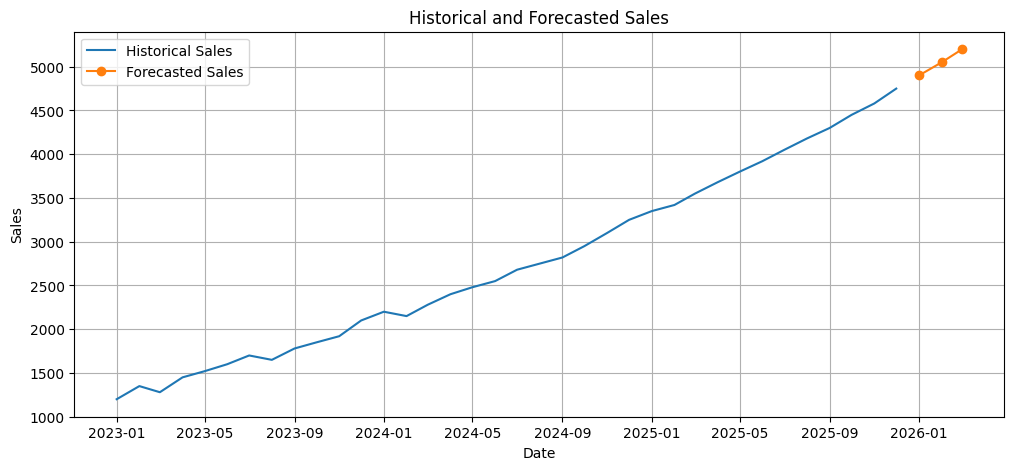

In [29]:
forecast_dates = pd.to_datetime([
    '2026-01-01',
    '2026-02-01',
    '2026-03-01'
])

plt.figure(figsize=(12,5))

plt.plot(
    df['Date'],
    df['Sales'],
    label='Historical Sales'
)

plt.plot(
    forecast_dates,
    future_predictions,
    marker='o',
    label='Forecasted Sales'
)

plt.title("Historical and Forecasted Sales")

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

In [33]:
forecast.to_csv("sales_forecast_results.csv", index=False)
print("Forecast results saved successfully!")

comparison.to_csv("actual_vs_predicted.csv", index=False)
print("Comparison file saved successfully!")

feature_importance.to_csv("feature_importance.csv", index=False)
print("Feature importance file saved successfully!")

import os

for file in os.listdir():
    print(file)

from google.colab import files

files.download("sales_forecast_results.csv")
files.download("actual_vs_predicted.csv")
files.download("feature_importance.csv")

Forecast results saved successfully!
Comparison file saved successfully!
Feature importance file saved successfully!
.config
sales_forecast_results.csv
feature_importance.csv
Sales_dataset (4).csv
Sales_dataset (2).csv
Sales_dataset (3).csv
Sales_dataset (1).csv
Sales_dataset.csv
actual_vs_predicted.csv
sample_data


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>